# 01 — Data Audit & Preprocessing Check

**Tujuan notebook ini:** dataset `dataset_merge_v2.csv` sudah melalui preprocessing (cleaning,
stopword removal, stemming) sebelum project ini dilanjutkan — tapi dataset mentah dan kode
preprocessing aslinya sudah hilang. Sebelum membangun model baru, kita perlu memverifikasi
secara menyeluruh:

1. Apakah teks di kolom `desc` benar-benar sudah bersih (tidak perlu preprocessing ulang)?
2. Apakah ada masalah kualitas data lain yang perlu diketahui sebelum modeling (duplikat,
   missing value, distribusi panjang teks, potensi *shortcut/leakage* yang bisa membuat model
   "curang")?
3. Apa saja temuan dari review notebook lama (`LSTM_GloVe_Final__with_GloVe_.ipynb`) yang
   perlu diperbaiki di pipeline baru?

Kesimpulan akhir notebook ini akan jadi dasar keputusan desain untuk
`02_LSTM_FastText_PyTorch.ipynb`.

## 1. Load dataset & overview dasar

In [2]:
import pandas as pd
import numpy as np
import re
from collections import Counter

pd.set_option('display.max_columns', 200)

df = pd.read_csv('../data/dataset_merge_v2.csv')
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nLabel distribution:")
print(df['label'].value_counts())

Shape: (9534, 5)

Columns: ['title', 'date', 'link', 'desc', 'label']

Missing values per column:
title    0
date     0
link     0
desc     0
label    0
dtype: int64

Label distribution:
label
VALID    8234
HOAX     1300
Name: count, dtype: int64


## 2. Cek Duplikat

Duplikat yang lolos ke tahap split train/val/test adalah sumber data leakage klasik kalau baris yang sama muncul di train dan test, akurasi test jadi tidak valid.

In [3]:
dup_desc = df['desc'].duplicated().sum()
dup_full = df.duplicated().sum()
print(f"Baris dengan 'desc' duplikat: {dup_desc}")
print(f"Baris duplikat penuh (semua kolom sama): {dup_full}")

if dup_desc > 0:
    print("\nContoh baris dengan desc duplikat:")
    display(df[df['desc'].duplicated(keep=False)].sort_values('desc').head(10))

Baris dengan 'desc' duplikat: 2
Baris duplikat penuh (semua kolom sama): 1

Contoh baris dengan desc duplikat:


,title,date,link,desc,label
5722,(HOAX) : Yusril Ihza Mahendra Menangkan Gugata...,Januari 16 2018,https://turnbackhoax.id/2018/01/16/hoax-yusril...,hoax berita palsu sesat sebar pihakpihak tangg...,HOAX
6814,[HOAX] Yusril Ihza Mahendra Menangkan Gugatan ...,Maret 20 2018,https://turnbackhoax.id/2018/03/20/hoax-yusril...,hoax berita palsu sesat sebar pihakpihak tangg...,HOAX
360,Anies Ungkit Politik Identitas di Pilkada 2017...,18 Mar 2023 15:40,https://news.detik.com/pemilu/d-6626085/anies-...,wakil ketua ppp arsul sani respons nyata bacap...,VALID
7641,Anies Ungkit Politik Identitas di Pilkada 2017...,18 Mar 2023 15:40,https://news.detik.com/pemilu/d-6626085/anies-...,wakil ketua ppp arsul sani respons nyata bacap...,VALID


**Temuan:** hanya ada 1-2 baris duplikat dari 9.534 total — dapat diabaikan/dihapus,
bukan masalah besar. Akan tetap kita drop di notebook 02 sebagai praktik yang baik.

## 3. Cek residu artefak preprocessing

Kalau preprocessing (cleaning, steaming, stopword removal) sudah benar-benar tuntas, seharusnya tidak ada lagi: URL, karakter uppercase, tanda baca, atau HTML entity yang tersisa di kolom `desc`.

In [4]:
url_pattern = re.compile(r'https?://|www\.')
html_entity_pattern = re.compile(r'&[a-z]+;|â€|Ã¢â‚¬')
punc_pattern = re.compile(r'[.,!?;:()"\'“”]')

checks = {
    'URL/link tersisa': df['desc'].astype(str).apply(lambda x: bool(url_pattern.search(x))),
    'HTML entity / encoding rusak tersisa': df['desc'].astype(str).apply(lambda x: bool(html_entity_pattern.search(x))),
    'Tanda baca tersisa': df['desc'].astype(str).apply(lambda x: bool(punc_pattern.search(x))),
}

for name, mask in checks.items():
    print(f"{name}: {mask.sum()} baris ({mask.mean()*100:.2f}%)")


URL/link tersisa: 0 baris (0.00%)
HTML entity / encoding rusak tersisa: 0 baris (0.00%)
Tanda baca tersisa: 0 baris (0.00%)


**Temuan: bersih.** Tidak ada URL, HTML entity, huruf kapital, atau tanda baca yang
tersisa. Ini mengkonfirmasi bahwa kolom `desc` **sudah melalui tahap cleaning + case folding
+ stemming (Sastrawi/ECS) yang lengkap**, konsisten dengan metodologi yang dijelaskan di paper
(Bagian III.B). Contoh sampel di bawah untuk verifikasi visual manual.

In [5]:
for lbl in ['VALID', 'HOAX']:
    print(f"=== Contoh 2 baris label {lbl} ===")
    for text in df[df['label'] == lbl]['desc'].head(2):
        print("-", text[:250], "...\n")

=== Contoh 2 baris label VALID ===
- ketua dewan timbang pusat generasi muda forum komunikasi putra putri purnawirawan putra putri tni polri gm fkppi ahmad basarah maklumat bangsa sikap politik gm fkppi kiblat sepenuh politik negara politik bangsa politik partisan sektarianhal nya tayan ...

- presiden joko widodo jokowi temu bilateral perdana menteri kanada justin trudeau isu kerja ekonomi kondisi sosial politik kawasan asean pembahasanpertemuan gelar hotel rihga royal hiroshima jepang sabtu 2052023 temu jokowi trudeau bahas janji kerja e ...

=== Contoh 2 baris label HOAX ===
- sudah klarifikasi putus surat cabut kepala desa rajeg yanto firmansyah sebut surat edar terbit miskomunikasi tak masalah tonjol lingkung surat miskomunikasi di apaapa yanto konfirmasi detikcom kamis 7122017 yanto surat edar viral musyawarah polisi pe ...

- informasi keliru foto momen kunjung yaqut cholil qoumas vatikan temu paus fransiskus september 2019 saat jabat ketua gp ansor menteri agama kategori kontek

### Kesimpulan Bagian 3
Berdasarkan pemeriksaan di atas: **teks di `desc` sudah bersih dan sudah melalui pipeline
preprocessing standar (cleaning → stopword removal → stemming)**, sama seperti yang
dideskripsikan di paper. **Tidak diperlukan preprocessing ulang dari sisi cleaning/stemming.**

Yang kita lakukan hanyalah *tokenization* dan *numericalization* baru untuk pipeline PyTorch
di notebook 02 (bukan mengulang cleaning/stemming).

## Distribusi panjang teks per kelas

Ini bagian penting: panjang teks yang berbeda jauh antar kelas bisa menjadi *shortcut* yang membuat model "curang", bukan belajar dari makna semantik teks, tapi hanya dari panjang sekuens / jumlah padding.

In [6]:
df['word_count'] = df['desc'].astype(str).apply(lambda x: len(x.split()))

summary = df.groupby('label')['word_count'].describe()
print(summary)

        count        mean         std   min    25%    50%    75%     max
label                                                                   
HOAX   1300.0  334.429231  326.034310  31.0  164.0  227.0  361.5  3530.0
VALID  8234.0  188.039835   76.227167  51.0  137.0  174.0  221.0  1351.0


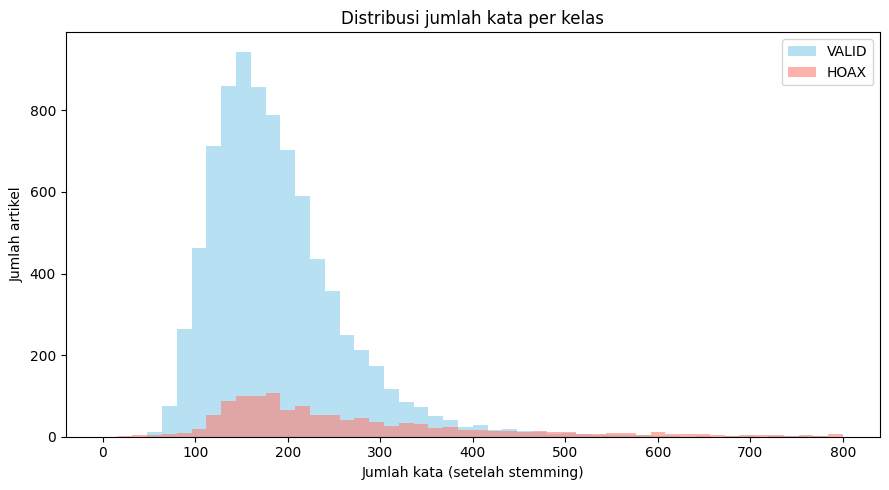

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, color in [('VALID', 'skyblue'), ('HOAX', 'salmon')]:
    subset = df[df['label'] == lbl]['word_count']
    ax.hist(subset, bins=50, alpha=0.6, label=lbl, color=color, range=(0, 800))
ax.set_xlabel('Jumlah kata (setelah stemming)')
ax.set_ylabel('Jumlah artikel')
ax.set_title('Distribusi jumlah kata per kelas')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/fig_word_count_distribution.png', dpi=120)
plt.show()

### ⚠️ Temuan penting: panjang teks berkorelasi kuat dengan label

Rata-rata panjang teks `HOAX` (~334 kata, std sangat besar ±326, maksimum sampai 3.530 kata)
jauh lebih panjang & lebih bervariasi dibanding `VALID` (~188 kata, std ±76, maksimum 1.351
kata).

**Kenapa ini masalah:** di notebook GloVe lama, `pad_sequences` menggunakan
`maxlen = max(len(seq) for seq in sequences)` — artinya SEMUA sekuens di-pad sampai
sepanjang urutan **terpanjang di seluruh dataset** (kemungkinan besar salah satu artikel
HOAX yang punya ~3.500 kata). Konsekuensinya:

- Artikel `VALID` yang jauh lebih pendek akan punya **padding (angka nol) dalam jumlah sangat
  banyak** di awal sekuensnya (Keras `pad_sequences` default pre-padding).
- Artikel `HOAX` cenderung punya padding jauh lebih sedikit.
- LSTM **bisa saja "curang"** dengan mendeteksi pola *jumlah padding* di awal sekuens sebagai
  proxy kelas — bukan belajar dari konten semantik artikelnya sama sekali.

Ini adalah salah satu kandidat penjelasan kenapa akurasi original bisa setinggi itu (98-99%)
meski embedding GloVe-nya (seperti ditemukan sebelumnya) sebagian besar berupa vektor nol.

**Perbaikan yang akan diterapkan di notebook 02:**
- `max_len` di-cap pada persentil yang wajar (mis. persentil ke-95 dari panjang teks **training
  set saja**), bukan panjang maksimum absolut di seluruh dataset.
- Truncation diterapkan untuk teks yang melebihi `max_len`.
- Ini membuat perbedaan jumlah padding antar kelas jauh lebih kecil, memaksa model belajar dari
  konten aktual dalam jendela yang wajar.

## 5. Cek potensi label leakage dari sumber data

Ingat: **semua** data `VALID` berasal dari detik.com dan **semua** data `HOAX` dari
turnbackhoax.id. Ini bukan hanya soal gaya penulisan berita vs gaya artikel fakta-cek — ada
risiko sistematis bahwa model belajar "ciri khas situs sumber", bukan "ciri khas berita hoax".
Kita sudah pastikan tidak ada residu URL/nama situs di teks (Bagian 3), tapi mari cek pola kata
pembuka/penutup yang boleh jadi merupakan boilerplate khas tiap situs.

In [9]:
# Cek kata pertama & kata terakhir paling umum per kelas -- boilerplate khas situs
# biasanya muncul di posisi yang konsisten (mis. selalu diawali/diakhiri kata yang sama)
#
# Catatan: sengaja TIDAK pakai groupby('label').apply(lambda s: Counter(...)) -- kalau
# fungsi apply mengembalikan objek mirip-dict (Counter), pandas GroupBy.apply akan
# "membongkar" isinya jadi Series baru alih-alih menyimpannya sebagai satu objek Counter
# utuh per grup, sehingga first_words[lbl] bukan Counter lagi dan .most_common() error
# (AttributeError: 'Series' object has no attribute 'most_common'). Filter manual per
# label di bawah ini menghindari masalah tersebut sepenuhnya.

for lbl in ['VALID', 'HOAX']:
    subset = df.loc[df['label'] == lbl, 'desc'].astype(str)
    first_word_counts = Counter(subset.str.split().str[0])
    print(f"=== 10 kata pembuka paling umum -- {lbl} ===")
    print(first_word_counts.most_common(10))
    print()


=== 10 kata pembuka paling umum -- VALID ===
[('ketua', 1458), ('partai', 427), ('wakil', 395), ('presiden', 322), ('menteri', 280), ('sekjen', 251), ('calon', 202), ('tum', 191), ('lembaga', 163), ('politikus', 162)]

=== 10 kata pembuka paling umum -- HOAX ===
[('hasil', 542), ('sumber', 54), ('foto', 45), ('bukan', 36), ('tidak', 31), ('informasi', 24), ('unggah', 19), ('video', 18), ('edar', 15), ('judul', 13)]



### ⚠️ Temuan besar: 41.7% artikel HOAX diawali kata "hasil" (vs 0.2% di VALID)

Hasil aktual dari cell di atas: kata pembuka **"hasil"** muncul di **542 dari 1.300 artikel
HOAX (41.7%)**, tapi hanya di **20 dari 8.234 artikel VALID (0.2%)**. Sampel teksnya:

```
hasil periksa fakta yudho ardi informasi palsu judul terang thumbnail video ...
hasil periksa fakta novita kusuma wardhani institut ilmu sosial ilmu politik ...
hasil periksa fakta aisyah adi anggota komisariat mafindo institut ilmu sosial ...
```

**Ini adalah boilerplate template artikel fact-check turnbackhoax.id/MAFINDO** — frasa
"hasil periksa fakta [nama fact-checker] [institusi]..." adalah format baku situs tersebut,
bukan konten berita yang sedang diperiksa. Ini bukan sinyal semantik "apa yang membuat
berita itu hoax" — ini sinyal "artikel ini berasal dari template fact-check MAFINDO".

**Implikasi serius:** sebuah classifier trivial ("kalau diawali kata 'hasil' → prediksi
HOAX") sudah akan benar untuk 542 dari 562 kasus di mana kata itu muncul (precision ~96.5%
hanya dari satu kata pertama saja) — tanpa perlu memahami bahasa sama sekali. Ini artinya
sebagian dari akurasi tinggi yang dilaporkan paper asli (dan kemungkinan juga akan tetap
terjadi di model revisi manapun, termasuk yang kita bangun di notebook 02) **bisa jadi
sebagian berasal dari mendeteksi template ini**, bukan murni dari memahami konten hoax.

**Ini TIDAK bisa "diperbaiki" tanpa mengubah komposisi dataset itu sendiri** (misal scraping
ulang & menghapus header template, atau mencari dataset dengan sumber HOAX yang lebih
beragam). Untuk scope revisi kali ini, kita **dokumentasikan secara eksplisit** sebagai
limitasi dataset yang sudah ada sejak awal (bukan sesuatu yang muncul akibat perubahan
embedding/model), dan akan dibahas lagi di notebook 03 saat menginterpretasikan hasil.

## 6. Review ulang bug metodologis di notebook GloVe lama

Selain temuan GloVe-vs-Bahasa-Indonesia yang sudah dikonfirmasi sebelumnya, review kode
`LSTM_GloVe_Final__with_GloVe_.ipynb` menemukan **satu masalah metodologis tambahan yang lebih
serius**, di cell "Apply SMOTE":

```python
smote = SMOTE(random_state=42, k_neighbors=4)
padded_sequences_res, integer_categories_res = smote.fit_resample(padded_sequences, integer_categories)
# ...
x_train, x_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
```

### ⚠️ Dua masalah dalam potongan kode ini:

1. **SMOTE diterapkan SEBELUM train/test split.** Ini data leakage klasik: SMOTE membuat
   sampel sintetis dengan interpolasi antar tetangga terdekat dari SELURUH data. Begitu
   `train_test_split` dijalankan setelahnya, sampel sintetis yang mirip satu sama lain bisa
   tersebar ke train DAN test/validation — artinya set "test" tidak lagi benar-benar
   independen. Ini bisa menjelaskan sebagian besar akurasi tinggi yang dilaporkan.

2. **SMOTE diterapkan langsung pada token ID hasil `pad_sequences` (bilangan bulat
   kategorikal), bukan pada representasi kontinu.** SMOTE bekerja dengan interpolasi linear
   antar titik data — cocok untuk fitur numerik kontinu, tapi *tidak masuk akal* untuk token ID
   (mis. interpolasi antara token ID 245 dan 812 menghasilkan "token" baru yang tidak
   berkorespondensi dengan kata nyata apa pun). Sampel HOAX sintetis hasil SMOTE ini kemungkinan
   berisi campuran token acak yang tidak membentuk kalimat bermakna — yang justru bisa membuat
   LSTM belajar mendeteksi "pola token acak = HOAX" alih-alih pola bahasa hoax yang sesungguhnya.

### Perbaikan yang akan diterapkan di notebook 02:
- **Split dulu (train/val/test), baru tangani ketidakseimbangan kelas — dan HANYA pada
  training set.** Validation & test set tetap representasi asli/alami dari distribusi data.
- **Ganti SMOTE-pada-token-ID dengan class-weighted loss function** (`nn.CrossEntropyLoss`
  dengan `weight=...` dihitung dari distribusi kelas training set). Ini pendekatan standar dan
  lebih defensible untuk data sekuens/teks — tidak menghasilkan token sintetis yang tidak
  bermakna, dan tidak menyentuh val/test set sama sekali.

## 7. Ringkasan Keputusan Desain untuk Notebook 02

| # | Temuan | Keputusan |
|---|---|---|
| 1 | Teks `desc` sudah bersih & sudah di-stem | **Tidak** perlu cleaning/stemming ulang — langsung tokenize |
| 2 | 1-2 baris duplikat | Drop duplikat sebelum split |
| 3 | Panjang teks HOAX jauh lebih panjang & bervariasi dari VALID | `max_len` di-cap ke persentil ke-95 training set + truncation, bukan `max()` mentah |
| 4 | 41.7% artikel HOAX diawali boilerplate "hasil periksa fakta..." (vs 0.2% di VALID) | Didokumentasikan sebagai limitasi dataset besar di notebook 03 — tidak bisa "diperbaiki" tanpa data baru |
| 5 | SMOTE diterapkan sebelum split → data leakage | Split dulu, baru tangani imbalance, hanya di training set |
| 6 | SMOTE pada token ID kategorikal → token sintetis tidak bermakna | Ganti dengan class-weighted loss |
| 7 | GloVe Inggris tidak cover vocab Indonesia, `trainable=False` | Ganti ke FastText Indonesia resmi (subword-aware, jadi tetap dapat vektor bermakna untuk kata hasil stemming yang bukan kata baku), `trainable=True` (fine-tune) |

Lanjut ke `02_LSTM_FastText_PyTorch.ipynb`.